# Range limitation

In this notebook, we will explain how the range of operation can be determined for a specific acquisition time and a specific false positive rate and true positive rate.

#### Plan of this notebook
1) Brief introduction to the algorithm needed to determine the range limitation
2) Implementing range limitation algorithm

# 1) Brief introduction to the algorithm needed to determine the range limitation

The goal is to determine the maximum range possible. Obviously, the possible range will depend on the parameters of the system. A higher power will yield an extended range. But this still begs the question: *how do we determine a cutoff distance ?*

It might be tempting to use the SNR. However, this metric is not sufficient as a target can always be detected assuming the SNR is non-zero. With SNR alone, it is difficult to precisely determine a range limitation. Hence, we need to add performance s that can be computed as a function of distance. Those metrics are
- The acquisition time
- The false positive rate
- The true positive rate

The acquisition time is the time needed to detect a target. Technically, if the SNR is non-zero, a target can be detected. But if an acquisition time of 5 days is necessary, then the system is far from being practical. Therefore, the acquisition time must be part of the range limitation.

The false positive rate is the rate at which the system detects a target when there is none. This is a critical metric as it determines the probability of detecting a target when there is none. 

The positive rate is the rate at which the system detects a target when there is one. This is also a critical metric as it determines the probability of detecting a target when there is one.

The last two parameters go hand in hand. We always want a true positive rate of 100% and a false positive rate of 0%, but obviously, this is not always possible. Generally, a high true detection rate result in a high false positive rate as the threshold is lowered to detect more targets. Inversely, a low false positive rate results in a low true positive rate as the threshold is increased to avoid false positives. In certain s, a "target" cannot be missed. In those scenarios, we prefer to have a high false positive rate to ensure that the target is detected (for example, in the context of a pandemic, we might want to detect everyone infected, even if it means false detecting healthy people). In other scenarios, we prefer to have a low false positive rate (to avoid wasting resources for example).

The ultimate distance cutoff is the distance at which those three metrics are no longer acceptable. The cutoff range will therefore change depending on the application.

To implement the algorithm, we begin by plotting the SNR as a function the distance. Even though the SNR is not sufficient to determine the cutoff distance, it is still a good starting point, and it gives us insight on the quantity of signals as compared to the noise. For each distance considered, the roc curve is computed for different acquisition time. Then, the distance at which the metrics are no longer acceptable is determined using ROC curves. Those distances can then plot using markers.

# 2) Implementing range limitation algorithm

The implementation of the range limitation is in the script `analysis.py`. First, let's import the necessary libraries and the script.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Analysis import RangeLimitation
from Sources import SetupParameters, PulsedLaser, SinglePhoton, EntangledPhotonSPDC

The variables needed in order to compute the range limitation are the following:

1) `params`: The SetupParams object that encapsulates the parameters of the system.
2) `match_multi_photon_probability`: This boolean variable determines if the multi-photon probability is fixed. If false, then the non-vacuum probability is fixed.
3) `range_interval`: The maximum distance that the system can operate. This distance must be bigger than the maximum distance considered. This variable determine the number of bins. If None, then the current distance considered will be the maximum distance. This allows to minimize the number of bins needed for each distance and to avoid using an arbitrary maximum distance.
4) `distance`: The distance considered. This has to be an array
5) `acquisition_time`: The acquisition time considered. This has to be an array. The time is in seconds.
6) `target_false_positive`: Acceptable false positive rate.
7) `target_true_positive`: Acceptable true positive rate.
8) `precision_roc`: This is the step size between two thresholds. The smaller the value, the more precise the ROC curve will be. However, this will also increase the computation time.
9) `threshold_limit_factor_roc`: The maximum threshold considered must be equal or higher to the maximum amount of signal possible. In the code, this is done by applying a factor on the triggering rate. The maximum threshold is therefore `trigger_rate/ threshold_limit_factor_roc`.

We can now define those parameters

In [10]:
param = SetupParameters(
	fock_space_dim=30,
	output_power=2e6,
	multi_photon_probability=None,
	no_vacuum_probability=None,
	number_nv_pulse=None,
	sp_collection=0.57,
	sp_p1=0.99,
	sp_p2=1e-3,
	spdc_eps_heralding=0.57*0.5,
	spdc_eps_collection=0.57,
	atmosphere=0.5,
	target_distance=None,
	receiver_diameter=0.05,
	target_albedo=0.5,
	optics_transmitter=0.8,
	optics_receiver=0.5,
	detection_efficiency=0.5,
	background=2.5e5,
	detector_dark=20,
	timing_window=0.5e-9,
)

match_multi_photon_probability = True
range_interval = None
distance = np.linspace(0.5, 40, 300)
acquisition_time = np.array([1, 60, 3600])
target_false_positive = 0.5
target_true_positive = 0.8
colored_marker = True
precision = 2
threshold_limit_factor = 100

We want to compute the range limitation for a false true positive of 50% and a true positive 80%. With those parameters, we accept to have many false positive. The acquisition time of 1s, 1min and 1h is considered. We can now run the algorithm.

The `colored_marker` will be used for plotting. If true, the marker will be coloured according to the curve. If false, the marker will be black.

The variables are then used as input for the object `RangeLimitation`. The method `compute` is then called to compute the range limitation.

In [11]:
results = RangeLimitation(
	params = param,
	parameter_to_match="number_nv_pulse",
	range_interval=range_interval,
	distance=distance,
	acquisition_time=acquisition_time,
	target_false_positive=target_false_positive,
	target_true_positive=target_true_positive,
	precision_roc=precision,
	threshold_limit_factor_roc=threshold_limit_factor,
	number_sps_array=10,
).compute()

100%|██████████| 300/300 [03:32<00:00,  1.41it/s]


Now, the output of the algorithm is a dictionary that contains the distance array, the SNR of all sources as well as the distance cutoff for each acquisition time.

In [12]:
distance = results["distance"]
snr_laser = results["snr_laser"]
snr_sps = results["snr_sps"]
snr_eps = results["snr_eps"]
distance_cutoff_laser = results["distance_cutoff_laser"]
distance_cutoff_sps = results["distance_cutoff_sps"]
distance_cutoff_eps = results["distance_cutoff_eps"]

The SNR as a function of the distance can then be plotted with the proper markers.

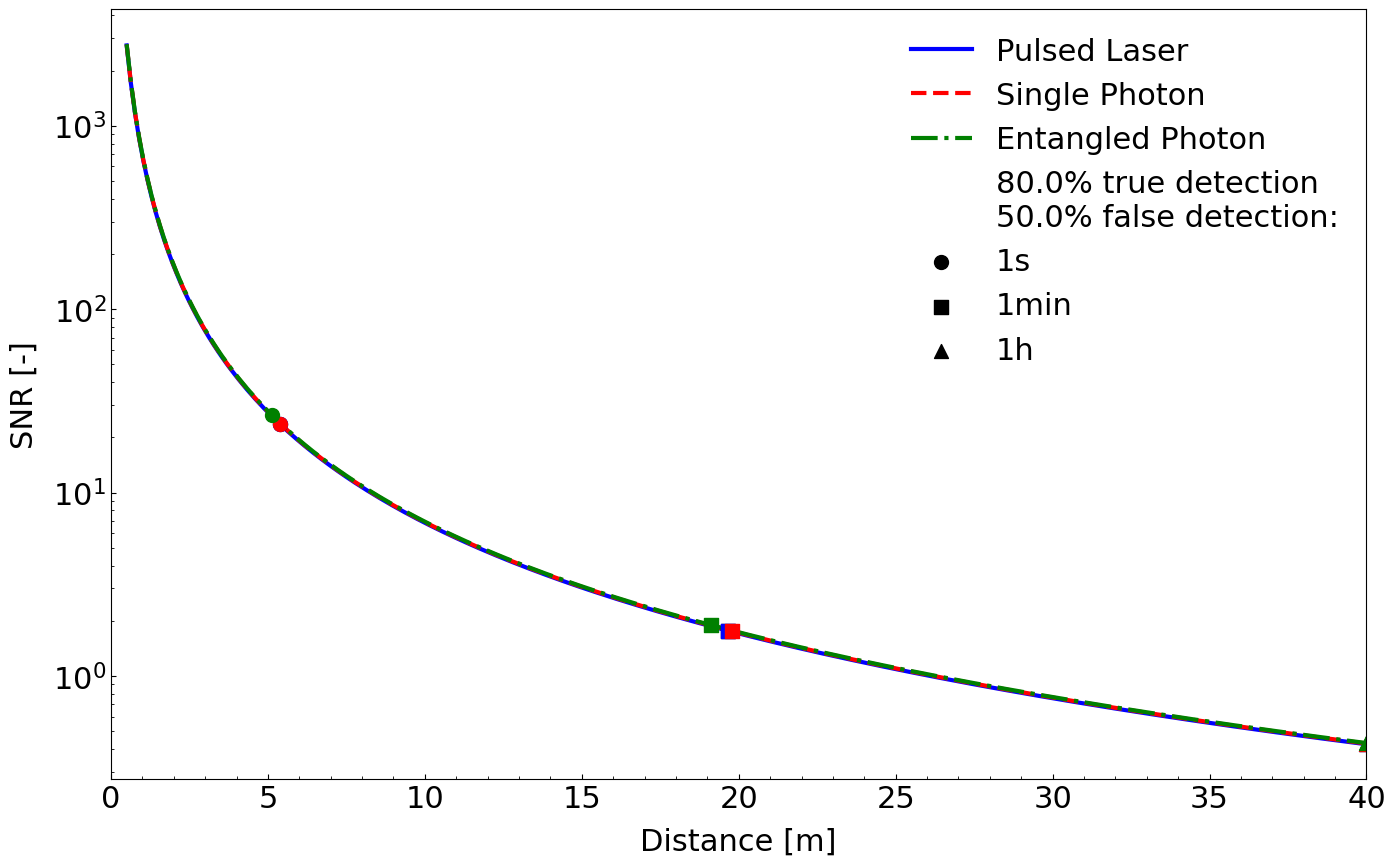

In [13]:
fig = plt.figure(figsize=(16.2, 10))

plt.style.use("https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-errorbars.mplstyle")

plt.semilogy(distance, snr_laser, "-", label="Pulsed Laser", linewidth=3, color="blue", zorder=1)
plt.semilogy(distance, snr_sps, "--", label="Single Photon", linewidth=3, color="red", zorder=1)
plt.semilogy(distance, snr_eps, "-.", label="Entangled Photon", linewidth=3, color="green", zorder=1)

plt.scatter(0, 0, label=f"{target_true_positive * 100}% true detection\n{target_false_positive * 100}% false detection:", alpha=0)

plt.scatter(distance_cutoff_laser[acquisition_time[0]], distance_cutoff_laser["snr_at0"], color="k", marker="o", s=100,
            label="1s", zorder=1)
plt.scatter(distance_cutoff_laser[acquisition_time[1]], distance_cutoff_laser["snr_at1"], color="k", marker="s", s=100,
            label="1min", zorder=1)
plt.scatter(distance_cutoff_laser[acquisition_time[2]], distance_cutoff_laser["snr_at2"], color="k", marker="^", s=100,
            label="1h", zorder=1)

str_maker_laser = "blue" if colored_marker else "k"
plt.scatter(distance_cutoff_laser[acquisition_time[0]], distance_cutoff_laser["snr_at0"], color=str_maker_laser,
            marker="o", s=100, zorder=2)
plt.scatter(distance_cutoff_laser[acquisition_time[1]], distance_cutoff_laser["snr_at1"], color=str_maker_laser,
            marker="s", s=100, zorder=2)
plt.scatter(distance_cutoff_laser[acquisition_time[2]], distance_cutoff_laser["snr_at2"], color=str_maker_laser,
            marker="^", s=100, zorder=2)

str_maker_sps = "red" if colored_marker else "k"
plt.scatter(distance_cutoff_sps[acquisition_time[0]], distance_cutoff_sps["snr_at0"], color=str_maker_sps, marker="o",
            s=100, zorder=2)
plt.scatter(distance_cutoff_sps[acquisition_time[1]], distance_cutoff_sps["snr_at1"], color=str_maker_sps, marker="s",
            s=100, zorder=2)
plt.scatter(distance_cutoff_sps[acquisition_time[2]], distance_cutoff_sps["snr_at2"], color=str_maker_sps, marker="^",
            s=100, zorder=2)

str_maker_eps = "green" if colored_marker else "k"
plt.scatter(distance_cutoff_eps[acquisition_time[0]], distance_cutoff_eps["snr_at0"], color=str_maker_eps, marker="o",
            s=100, zorder=2)
plt.scatter(distance_cutoff_eps[acquisition_time[1]], distance_cutoff_eps["snr_at1"], color=str_maker_eps, marker="s",
            s=100, zorder=2)
plt.scatter(distance_cutoff_eps[acquisition_time[2]], distance_cutoff_eps["snr_at2"], color=str_maker_eps, marker="^",
            s=100, zorder=2)

plt.xlabel("Distance [m]", fontsize=22)
plt.ylabel("SNR [-]", fontsize=22)
plt.legend(fontsize=22, frameon=False)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.xlim([0, 40])
plt.show()